# Global Solution - MLAM

## Analise estatistica de exoplanetas

Este notebook utiliza uma base real do NASA Exoplanet Archive para fazer uma analise exploratoria simples em Python.

## 1. Selecao e justificativa da base de dados

A base escolhida contem dados reais de exoplanetas confirmados, incluindo ano de descoberta, metodo de descoberta, periodo orbital, raio, massa e distancia do sistema.

Ela foi escolhida porque esta diretamente ligada ao tema espacial e permite trabalhar com variaveis quantitativas discretas e continuas. Alem disso, os dados sao publicos e possuem potencial para apoiar analises sobre observacao astronomica e tecnologias ligadas a nova economia espacial.

Fonte: NASA Exoplanet Archive - https://exoplanetarchive.ipac.caltech.edu/

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

dados = pd.read_csv('exoplanetas_nasa.csv')
dados = dados.dropna(subset=['disc_year', 'pl_orbper', 'pl_rade', 'pl_bmasse', 'sy_dist'])
dados['disc_year'] = dados['disc_year'].astype(int)

print('Quantidade de registros usados:', len(dados))
print('Colunas da base:')
print(dados.columns)

Quantidade de registros usados: 1473
Colunas da base:
Index(['pl_name', 'hostname', 'discoverymethod', 'disc_year', 'pl_orbper',
       'pl_rade', 'pl_bmasse', 'sy_dist'],
      dtype='object')


## 2. Tabela de frequencia - variavel quantitativa discreta

Variavel escolhida: `disc_year`, que representa o ano de descoberta do exoplaneta.

In [2]:
tabela_ano = dados['disc_year'].value_counts().sort_index().reset_index()
tabela_ano.columns = ['ano_descoberta', 'frequencia']
tabela_ano['percentual'] = tabela_ano['frequencia'] / len(dados) * 100
tabela_ano['frequencia_acumulada'] = tabela_ano['frequencia'].cumsum()

tabela_ano

ano_descoberta,frequencia,percentual,frequencia_acumulada
1999,1,0.067889,1
2001,1,0.067889,2
2004,6,0.407332,8
2005,3,0.203666,11
2006,3,0.203666,14
2007,15,1.018330,29
2008,17,1.154107,46
2009,18,1.221996,64
2010,43,2.919212,107
2011,71,4.820095,178


## 3. Tabela de frequencia - variavel quantitativa continua

Variavel escolhida: `pl_orbper`, que representa o periodo orbital do planeta em dias. Como e uma variavel continua, foram criados intervalos.

In [3]:
intervalos = [0, 1, 5, 10, 20, 50, 100, 500, dados['pl_orbper'].max()]
nomes_intervalos = [
    '0 a 1 dia',
    '1 a 5 dias',
    '5 a 10 dias',
    '10 a 20 dias',
    '20 a 50 dias',
    '50 a 100 dias',
    '100 a 500 dias',
    'mais de 500 dias',
]

intervalos_orbita = pd.cut(
    dados['pl_orbper'],
    bins=intervalos,
    labels=nomes_intervalos,
    include_lowest=True
)

tabela_orbita = intervalos_orbita.value_counts().sort_index().reset_index()
tabela_orbita.columns = ['intervalo_periodo_orbital', 'frequencia']
tabela_orbita['percentual'] = tabela_orbita['frequencia'] / len(dados) * 100

tabela_orbita

intervalo_periodo_orbital,frequencia,percentual
0 a 1 dia,58,3.937542
1 a 5 dias,682,46.300068
5 a 10 dias,272,18.465716
10 a 20 dias,206,13.985064
20 a 50 dias,142,9.640190
50 a 100 dias,52,3.530210
100 a 500 dias,49,3.326544
mais de 500 dias,12,0.814664


## 4. Graficos estatisticos

Foram criados dois graficos com variaveis diferentes da base.

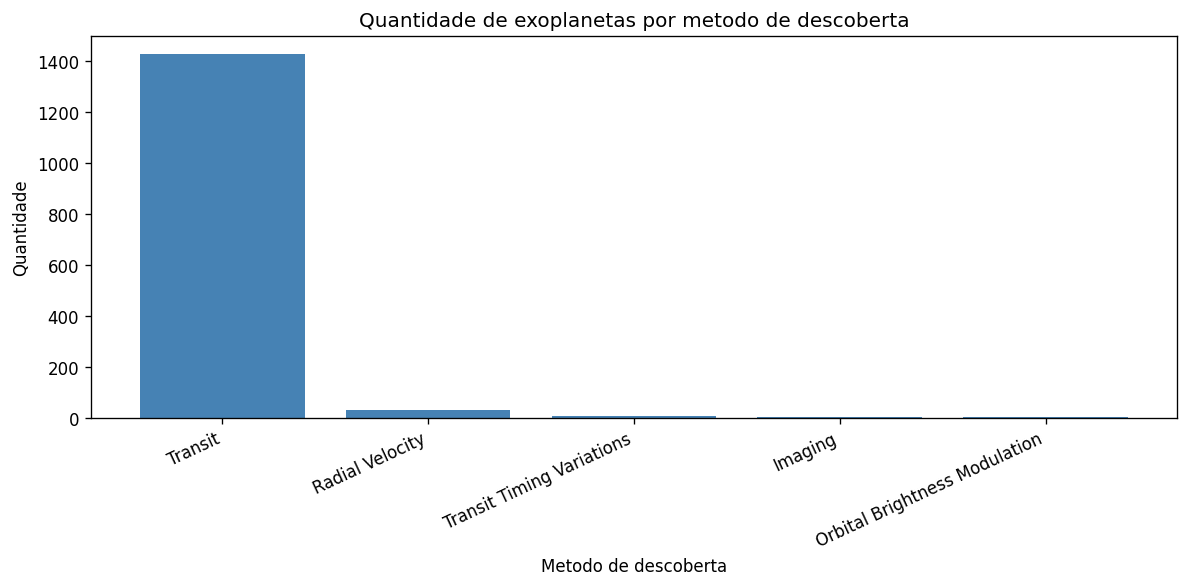

In [4]:
metodos = dados['discoverymethod'].value_counts().head(6)

plt.figure(figsize=(10, 5))
plt.bar(metodos.index, metodos.values, color='steelblue')
plt.title('Quantidade de exoplanetas por metodo de descoberta')
plt.xlabel('Metodo de descoberta')
plt.ylabel('Quantidade')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

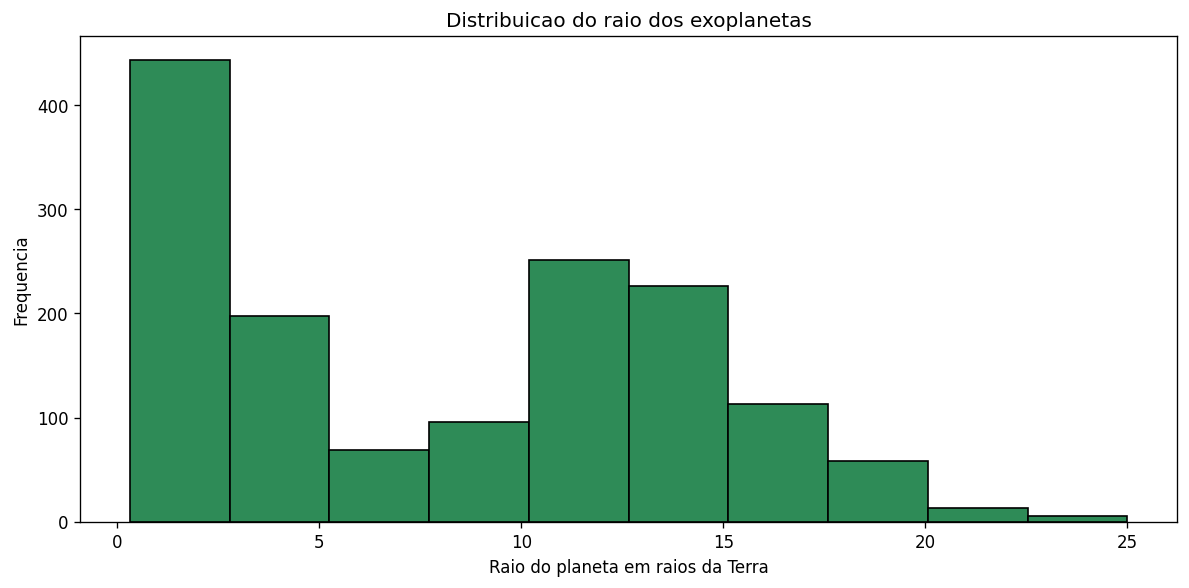

In [5]:
plt.figure(figsize=(10, 5))
plt.hist(dados['pl_rade'], bins=10, color='seagreen', edgecolor='black')
plt.title('Distribuicao do raio dos exoplanetas')
plt.xlabel('Raio do planeta em raios da Terra')
plt.ylabel('Frequencia')
plt.tight_layout()
plt.show()

## 5. Analises univariadas com estatistica descritiva

Foram analisadas duas variaveis: periodo orbital e raio do planeta.

In [6]:
def calcular_estatisticas(nome_variavel, coluna):
    return {
        'variavel': nome_variavel,
        'media': coluna.mean(),
        'mediana': coluna.median(),
        'moda': coluna.mode().iloc[0],
        'maximo': coluna.max(),
        'minimo': coluna.min(),
        'amplitude': coluna.max() - coluna.min(),
        'variancia': coluna.var(),
        'desvio_padrao': coluna.std(),
        'quartil_1': coluna.quantile(0.25),
        'quartil_2': coluna.quantile(0.50),
        'quartil_3': coluna.quantile(0.75),
    }

estatisticas = pd.DataFrame([
    calcular_estatisticas('Periodo orbital em dias', dados['pl_orbper']),
    calcular_estatisticas('Raio do planeta em raios da Terra', dados['pl_rade']),
])

estatisticas

variavel,media,mediana,moda,maximo,minimo,amplitude,variancia,desvio_padrao,quartil_1,quartil_2,quartil_3
Periodo orbital em dias,291.724618,4.954642,0.112007,170000.0,0.112007,169999.887993,3.303230e+07,5747.373175,3.110413,4.954642,12.998940
Raio do planeta em raios da Terra,8.267911,8.608497,14.571700,25.0,0.309800,24.690200,3.356242e+01,5.793308,2.517000,8.608497,13.092089


## 6. Interpretacao dos resultados

- O ano de descoberta foi usado como variavel quantitativa discreta e mostra como os registros aparecem ao longo do tempo.
- A variavel periodo orbital foi agrupada em intervalos, pois possui muitos valores diferentes.
- A maior parte dos planetas analisados possui periodo orbital entre 1 e 20 dias.
- O grafico de metodos mostra forte concentracao no metodo Transit.
- O periodo orbital possui media maior que a mediana, indicando influencia de valores extremos.
- As medidas de dispersao mostram que os dados astronomicos podem variar bastante, entao medias devem ser analisadas com cuidado.

De forma geral, a base atende ao objetivo de transformar dados reais em informacoes uteis para uma analise estatistica inicial no contexto espacial.